# Self-Consistent Stochastic Interpolants — MRA Channel with U-Net

Based on: https://arxiv.org/abs/2512.10857

**Channel:** `Y = T(X) + σ·w` (random circular shift + AWGN)

Uses the same standard U-Net architecture as the AWGN variant (no built-in
equivariance/invariance). This tests whether the EM iteration can make progress
on the harder MRA inverse problem without architectural symmetry constraints.

Supports CUDA, Apple Silicon MPS, and CPU.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        desc = kwargs.get("desc", "")
        if desc:
            print(desc, flush=True)
        return iterable

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

Device: cuda


## 1. Forward Channel

`Y = T(X) + σ·w` where **T** is a uniform random 2-D circular shift and **w** is AWGN.

In [3]:
def random_circular_shift(x: torch.Tensor) -> torch.Tensor:
    """Vectorised random 2D circular shift via the FFT shift theorem."""
    B, C, H, W = x.shape
    sh = torch.randint(0, H, (B,), device=x.device)
    sw = torch.randint(0, W, (B,), device=x.device)
    ky = torch.arange(H, device=x.device, dtype=torch.float32)
    kx = torch.arange(W, device=x.device, dtype=torch.float32)
    ky, kx = torch.meshgrid(ky, kx, indexing="ij")
    phase = -2.0 * math.pi * (
        sh[:, None, None].float() * ky[None] / H
        + sw[:, None, None].float() * kx[None] / W
    )
    kernel = torch.polar(torch.ones_like(phase), phase).unsqueeze(1)
    return torch.fft.ifft2(torch.fft.fft2(x) * kernel).real


def forward_channel(x: torch.Tensor, sigma: float = 0.5) -> torch.Tensor:
    """Y = T(X) + σ·w, T ~ uniform random circular shift."""
    return random_circular_shift(x) + sigma * torch.randn_like(x)

## 2. U-Net Architecture

Standard U-Net for MNIST 28×28 with sinusoidal time embeddings and FiLM conditioning.

- **Input:** `(x_t, y)` concatenated → 2 channels
- **Output:** velocity prediction → 1 channel
- **Encoder:** 28×28 → 14×14 → 7×7
- **Decoder:** 7×7 → 14×14 → 28×28 (with skip connections)

In [4]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1)
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10_000) * torch.arange(half, device=t.device) / half
        )
        args = t[:, None] * freqs[None]
        emb = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.mlp(emb)


class ResBlock(nn.Module):
    """ResNet block with FiLM time conditioning."""
    def __init__(self, in_ch: int, out_ch: int, t_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.film = nn.Linear(t_dim, 2 * out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = F.gelu(self.norm1(self.conv1(x)))
        gamma, beta = self.film(t_emb).chunk(2, dim=-1)
        h = h * (1.0 + gamma[:, :, None, None]) + beta[:, :, None, None]
        h = F.gelu(self.norm2(self.conv2(h)))
        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)

class CleanUNet(nn.Module):
    """
    Clean U-Net for MNIST 28×28 with y conditioning at every scale.
    Version 2, injects y at every scale."""
    def __init__(self, base_ch: int = 64, t_dim: int = 128):
        super().__init__()
        c1, c2, c3 = base_ch, base_ch * 2, base_ch * 4
        self.time_emb = SinusoidalTimeEmb(t_dim)

        # Encoder
        # Each block's input gets y concatenated (+1 channel)
        self.enc1a = ResBlock(2 + 1, c1, t_dim)         # x_t + y (input) + y (multiscale concat)
        self.enc1b = ResBlock(c1 + 1, c1, t_dim)
        self.down1 = Downsample(c1)                     # 28→14

        self.enc2a = ResBlock(c1 + 1, c2, t_dim)
        self.enc2b = ResBlock(c2 + 1, c2, t_dim)
        self.down2 = Downsample(c2)                     # 14→7

        # Bottleneck
        self.mid1 = ResBlock(c2 + 1, c3, t_dim)
        self.mid2 = ResBlock(c3 + 1, c3, t_dim)

        # Decoder
        self.up2 = Upsample(c3)                         # 7→14
        self.dec2a = ResBlock(c3 + c2 + 1, c2, t_dim)   # skip + y
        self.dec2b = ResBlock(c2 + 1, c2, t_dim)

        self.up1 = Upsample(c2)                         # 14→28
        self.dec1a = ResBlock(c2 + c1 + 1, c1, t_dim)   # skip + y
        self.dec1b = ResBlock(c1 + 1, c1, t_dim)

        self.out = nn.Sequential(
            nn.GroupNorm(8, c1), nn.GELU(),
            nn.Conv2d(c1, 1, 3, padding=1),
        )

    def forward(self, x_t, y, t):
        t_emb = self.time_emb(t)

        # Multi-scale y
        y_28 = y                                        # [B, 1, 28, 28]
        y_14 = F.avg_pool2d(y, 2)                       # [B, 1, 14, 14]
        y_7  = F.avg_pool2d(y, 4)                       # [B, 1, 7, 7]

        def cat_y(h, y_scale):
            return torch.cat([h, y_scale], dim=1)

        # Encoder (28×28)
        inp = torch.cat([x_t, y_28], dim=1)             # [B, 2, 28, 28]
        h1 = self.enc1a(cat_y(inp, y_28), t_emb)
        h1 = self.enc1b(cat_y(h1, y_28), t_emb)

        # Encoder (14×14)
        h2 = self.down1(h1)
        h2 = self.enc2a(cat_y(h2, y_14), t_emb)
        h2 = self.enc2b(cat_y(h2, y_14), t_emb)

        # Bottleneck (7×7)
        h = self.down2(h2)
        h = self.mid1(cat_y(h, y_7), t_emb)
        h = self.mid2(cat_y(h, y_7), t_emb)

        # Decoder (14×14)
        h = self.up2(h)
        h = self.dec2a(cat_y(torch.cat([h, h2], dim=1), y_14), t_emb)
        h = self.dec2b(cat_y(h, y_14), t_emb)

        # Decoder (28×28)
        h = self.up1(h)
        h = self.dec1a(cat_y(torch.cat([h, h1], dim=1), y_28), t_emb)
        h = self.dec1b(cat_y(h, y_28), t_emb)

        return self.out(h)

# class CleanUNet(nn.Module):
#     """Clean U-Net for MNIST 28×28. Version 1"""
#     def __init__(self, base_ch: int = 64, t_dim: int = 128):
#         super().__init__()
#         c1, c2, c3 = base_ch, base_ch * 2, base_ch * 4

#         self.time_emb = SinusoidalTimeEmb(t_dim)

#         # Encoder
#         self.enc1a = ResBlock(2, c1, t_dim)
#         self.enc1b = ResBlock(c1, c1, t_dim)
#         self.down1 = Downsample(c1)                  # 28→14

#         self.enc2a = ResBlock(c1, c2, t_dim)
#         self.enc2b = ResBlock(c2, c2, t_dim)
#         self.down2 = Downsample(c2)                  # 14→7

#         # Bottleneck
#         self.mid1 = ResBlock(c2, c3, t_dim)
#         self.mid2 = ResBlock(c3, c3, t_dim)

#         # Decoder
#         self.up2 = Upsample(c3)                      # 7→14
#         self.dec2a = ResBlock(c3 + c2, c2, t_dim)
#         self.dec2b = ResBlock(c2, c2, t_dim)

#         self.up1 = Upsample(c2)                      # 14→28
#         self.dec1a = ResBlock(c2 + c1, c1, t_dim)
#         self.dec1b = ResBlock(c1, c1, t_dim)

#         self.out = nn.Sequential(
#             nn.GroupNorm(8, c1), nn.GELU(),
#             nn.Conv2d(c1, 1, 3, padding=1),
#         )

#     def forward(self, x_t, y, t):
#         t_emb = self.time_emb(t)
#         inp = torch.cat([x_t, y], dim=1)             # [B, 2, 28, 28]

#         # Encoder
#         h1 = self.enc1b(self.enc1a(inp, t_emb), t_emb)
#         h2 = self.enc2b(self.enc2a(self.down1(h1), t_emb), t_emb)

#         # Bottleneck
#         h = self.mid2(self.mid1(self.down2(h2), t_emb), t_emb)

#         # Decoder
#         h = self.up2(h)
#         h = self.dec2b(self.dec2a(torch.cat([h, h2], dim=1), t_emb), t_emb)

#         h = self.up1(h)
#         h = self.dec1b(self.dec1a(torch.cat([h, h1], dim=1), t_emb), t_emb)

#         return self.out(h)

In [5]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def circ_conv(in_ch, out_ch, k=3, stride=1):
    """Conv2d with circular padding."""
    pad = k // 2
    return nn.Conv2d(in_ch, out_ch, k, stride=stride,
                     padding=pad, padding_mode='circular')


class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1)
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10_000) * torch.arange(half, device=t.device) / half
        )
        args = t[:, None] * freqs[None]
        emb = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.mlp(emb)


class ResBlock(nn.Module):
    """ResNet block with FiLM time conditioning, circular padding."""
    def __init__(self, in_ch: int, out_ch: int, t_dim: int):
        super().__init__()
        self.conv1 = circ_conv(in_ch, out_ch, 3)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = circ_conv(out_ch, out_ch, 3)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.film = nn.Linear(t_dim, 2 * out_ch)
        # 1x1 skip — no padding needed
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = F.gelu(self.norm1(self.conv1(x)))
        gamma, beta = self.film(t_emb).chunk(2, dim=-1)
        h = h * (1.0 + gamma[:, :, None, None]) + beta[:, :, None, None]
        h = F.gelu(self.norm2(self.conv2(h)))
        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.conv = circ_conv(ch, ch, 3, stride=2)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.conv = circ_conv(ch, ch, 3)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


class CircularUNet(nn.Module):
    """Translation-equivariant U-Net for MNIST 32×32 (pad MNIST to 32)."""
    def __init__(self, base_ch: int = 64, t_dim: int = 128):
        super().__init__()
        c1, c2, c3 = base_ch, base_ch * 2, base_ch * 4
        self.time_emb = SinusoidalTimeEmb(t_dim)

        self.enc1a = ResBlock(2, c1, t_dim)
        self.enc1b = ResBlock(c1, c1, t_dim)
        self.down1 = Downsample(c1)                 # 32→16

        self.enc2a = ResBlock(c1, c2, t_dim)
        self.enc2b = ResBlock(c2, c2, t_dim)
        self.down2 = Downsample(c2)                 # 16→8

        self.mid1 = ResBlock(c2, c3, t_dim)
        self.mid2 = ResBlock(c3, c3, t_dim)

        self.up2 = Upsample(c3)                     # 8→16
        self.dec2a = ResBlock(c3 + c2, c2, t_dim)
        self.dec2b = ResBlock(c2, c2, t_dim)

        self.up1 = Upsample(c2)                     # 16→32
        self.dec1a = ResBlock(c2 + c1, c1, t_dim)
        self.dec1b = ResBlock(c1, c1, t_dim)

        self.out = nn.Sequential(
            nn.GroupNorm(8, c1), nn.GELU(),
            circ_conv(c1, 1, 3),
        )

    def forward(self, x_t, y, t):
        t_emb = self.time_emb(t)
        inp = torch.cat([x_t, y], dim=1)
        h1 = self.enc1b(self.enc1a(inp, t_emb), t_emb)
        h2 = self.enc2b(self.enc2a(self.down1(h1), t_emb), t_emb)
        h = self.mid2(self.mid1(self.down2(h2), t_emb), t_emb)
        h = self.up2(h)
        h = self.dec2b(self.dec2a(torch.cat([h, h2], dim=1), t_emb), t_emb)
        h = self.up1(h)
        h = self.dec1b(self.dec1a(torch.cat([h, h1], dim=1), t_emb), t_emb)
        return self.out(h)

## 3. Flow-Matching Loss & Sampling

Straight-path flow matching between the data distribution and a standard Gaussian.

In [6]:
def flow_matching_loss(model, x, y):
    B = x.size(0)
    t = torch.rand(B, device=x.device)
    w = torch.randn_like(x)
    t4 = t[:, None, None, None]
    x_t = (1.0 - t4) * x + t4 * w
    target = w - x
    pred = model(x_t, y, t)
    return F.mse_loss(pred, target)


@torch.no_grad()
def sample_midpoint(model, y, n_steps=50, initial_state=None):
    model.eval()
    B = y.size(0)
    if initial_state is None:
        x_t = torch.randn(B, 1, 28, 28, device=y.device)
    else:
        if initial_state.shape != (B, 1, 28, 28):
            raise ValueError('wrong shape in `initial_state`')
        x_t = initial_state
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t_val = 1.0 - i * dt
        t = torch.full((B,), t_val, device=y.device)
        v1 = model(x_t, y, t)
        x_mid = x_t - v1 * (dt / 2.0)
        t_mid = torch.full((B,), t_val - dt / 2.0, device=y.device)
        v2 = model(x_mid, y, t_mid)
        x_t = x_t - v2 * dt
    return x_t

## 4. E-step: Train Conditional Model

Given the current prior `x_pool`, synthesise observations on the fly and train the
flow-matching model `p(x | y)`.

In [7]:
def train_conditional(model, x_pool, sigma, epochs=10, batch_size=256, lr=3e-4):
    loader = DataLoader(
        TensorDataset(x_pool),
        batch_size=batch_size, shuffle=True,
        num_workers=4, pin_memory=(DEVICE.type == "cuda"), drop_last=True, prefetch_factor=4,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for (x_batch,) in tqdm(loader, desc=f"  E-step epoch {epoch}/{epochs}",
                                leave=False):
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = forward_channel(x_batch, sigma=sigma)

            loss = flow_matching_loss(model, x_batch, y_batch)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()

        # sched.step()
        avg = running / len(loader)
        print(f"    epoch {epoch:2d}  |  loss = {avg:.5f}")

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()

## 5. Noise-Level Estimator

Robust MAD-based estimator: `σ̂ = median(|x_i|) / 0.6745`

In [8]:
def estimate_noise_mad(x: torch.Tensor) -> float:
    """Estimate noise σ via MAD: σ̂ = median(|x_i|) / 0.6745"""
    return x.abs().median().item() / 0.6745

## 6. M-step: Update Prior

Push real observations through the trained model to obtain the new prior `π^(k+1)`.

In [9]:
@torch.no_grad()
def update_prior(model, y_obs, n_steps=50, batch_size=512):
    model.eval()
    N = y_obs.size(0)
    result_gpu = torch.empty(N, 1, 28, 28, device=DEVICE)
    y_gpu = y_obs.to(DEVICE)

    for start in tqdm(range(0, N, batch_size), desc="  M-step", leave=False):
        end = min(start + batch_size, N)
        x_batch = sample_midpoint(model, y_gpu[start:end], n_steps=n_steps)
        result_gpu[start:end] = x_batch

    result = result_gpu.cpu()
    del result_gpu, y_gpu

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()
    return result

## 7. Visualisation

Saves a grid of images (GT, observations, and each EM prior iteration) alongside
pixel-value histograms with MAD noise estimates.

In [10]:
def visualise_em(y_obs, x_gt, prior_history, n=8, path="em_mra_unet_results.png"):
    import matplotlib.pyplot as plt

    def to_img(t):
        lo, hi = t.min(), t.max()
        if hi - lo < 1e-8:
            return torch.zeros_like(t)
        return (t - lo) / (hi - lo)

    rows = [
        ("π (GT)", x_gt[:n], x_gt),
        ("μ (obs)", y_obs[:n], y_obs),
    ]
    for k, x_pool in enumerate(prior_history):
        rows.append((f"π({k})", x_pool[:n], x_pool))

    n_rows = len(rows)
    fig, axes = plt.subplots(n_rows, n + 1, figsize=(2 * (n + 1), 2.2 * n_rows),
                             gridspec_kw={"width_ratios": [1] * n + [1.5]})

    for row_idx, (label, imgs, full_tensor) in enumerate(rows):
        for j in range(n):
            axes[row_idx, j].imshow(
                to_img(imgs[j, 0]), cmap="gray", vmin=0, vmax=1,
            )
            axes[row_idx, j].axis("off")

        ax_hist = axes[row_idx, n]
        vals = full_tensor.flatten().numpy()
        ax_hist.hist(vals, bins=100, density=True, color="steelblue",
                     alpha=0.7, edgecolor="none")
        sigma_hat = estimate_noise_mad(full_tensor)
        ax_hist.set_title(f"σ̂ = {sigma_hat:.3f}", fontsize=9)
        ax_hist.set_xlim(-4, 4)
        ax_hist.tick_params(labelsize=7)
        ax_hist.set_yticks([])

        axes[row_idx, 0].set_ylabel(label, fontsize=10)

    fig.suptitle("Self-Consistent Flow Matching — MRA channel (U-Net)", fontsize=13)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved → {path}")

## 8. Run: Hyperparameters

Adjust these before running the EM loop.

In [11]:
# Channel
sigma_noise = 0.5

# EM schedule
n_em_steps       = 3
epochs           = 100
sample_steps     = 50

# Training
batch_size = 516
lr         = 3e-4
n_obs      = 2_000  # observations drawn from MNIST

## 9. Run: Load Data & Generate Observations

Downloads MNIST, normalises the ground-truth images, and applies the MRA forward
channel to create `y_obs`.

In [12]:
transform = transforms.ToTensor()
dataset = torchvision.datasets.MNIST(
    "./data", train=True, download=True, transform=transform,
)
full_loader = DataLoader(
    dataset,
    batch_size=n_obs,                # fits in GPU memory; tune per model
    num_workers=4,                 # ~4–16 depending on CPU cores per GPU
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
)
x_gt_all, _ = next(iter(full_loader))

# Standardise GT to mean=0, std=1
gt_mean = x_gt_all.mean()
gt_std  = x_gt_all.std().clamp(min=1e-6)
x_gt_all = (x_gt_all - gt_mean) / gt_std
print(f"GT normalised: mean={x_gt_all.mean():.4f}, std={x_gt_all.std():.4f}")

y_obs = forward_channel(x_gt_all, sigma=sigma_noise)

print(f"Observations:    {y_obs.shape[0]}")
print(f"Channel:         MRA (shift + AWGN)  σ={sigma_noise}")
print(f"EM steps:        {n_em_steps}")

sigma_gt  = estimate_noise_mad(x_gt_all)
sigma_obs = estimate_noise_mad(y_obs)
print(f"\nNoise estimates (MAD):")
print(f"  π (GT):  σ̂ = {sigma_gt:.3f}")
print(f"  μ (obs): σ̂ = {sigma_obs:.3f}")
x_gt_all, _ = next(iter(full_loader))

# Standardise GT to mean=0, std=1
gt_mean = x_gt_all.mean()
gt_std  = x_gt_all.std().clamp(min=1e-6)
x_gt_all = (x_gt_all - gt_mean) / gt_std
print(f"GT normalised: mean={x_gt_all.mean():.4f}, std={x_gt_all.std():.4f}")

y_obs = forward_channel(x_gt_all, sigma=sigma_noise)

print(f"Observations:    {y_obs.shape[0]}")
print(f"Channel:         MRA (shift + AWGN)  σ={sigma_noise}")
print(f"EM steps:        {n_em_steps}")

sigma_gt  = estimate_noise_mad(x_gt_all)
sigma_obs = estimate_noise_mad(y_obs)
print(f"\nNoise estimates (MAD):")
print(f"  π (GT):  σ̂ = {sigma_gt:.3f}")
print(f"  μ (obs): σ̂ = {sigma_obs:.3f}")

GT normalised: mean=-0.0000, std=1.0000
Observations:    2000
Channel:         MRA (shift + AWGN)  σ=0.5
EM steps:        3

Noise estimates (MAD):
  π (GT):  σ̂ = 0.627
  μ (obs): σ̂ = 0.821
GT normalised: mean=-0.0000, std=1.0000
Observations:    2000
Channel:         MRA (shift + AWGN)  σ=0.5
EM steps:        3

Noise estimates (MAD):
  π (GT):  σ̂ = 0.627
  μ (obs): σ̂ = 0.821


## 10. Run: EM Loop

Iterates E-step (train conditional model) and M-step (update prior via sampling).
Checkpoints and prior tensors are saved to disk after each iteration.

In [13]:
# Bootstrap: π^(0) = μ (observations as initial X-pool)
x_pool = y_obs.clone()
prior_history = [x_pool.clone()]
print(f"  π(0): σ̂ = {estimate_noise_mad(x_pool):.3f}\n")


# E-step: fresh model, train on current prior
# model = CleanUNet(base_ch=64, t_dim=128).to(DEVICE)
model = CircularUNet(base_ch=64, t_dim=128).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

  π(0): σ̂ = 0.821

Parameters: 5,293,825


In [24]:
train_conditional(
    model, x_pool, sigma=sigma_noise,
    epochs=1_500, batch_size=batch_size, lr=lr,
)

    epoch  1  |  loss = 0.95763


    epoch  2  |  loss = 0.83286


    epoch  3  |  loss = 0.71188


    epoch  4  |  loss = 0.60404


    epoch  5  |  loss = 0.58940


...

    epoch 308  |  loss = 0.42457


    epoch 309  |  loss = 0.43597


    epoch 310  |  loss = 0.45055


    epoch 311  |  loss = 0.45770


KeyboardInterrupt: 

## 11. Run: Visualise Results

Saves a PNG with ground-truth, observations, and all EM prior iterates.

In [25]:
observation = y_obs[:8]
fixed_initialization = torch.randn(1, 1, 28, 28).repeat(8, 1, 1, 1).to(DEVICE)
prediction = sample_midpoint(model, y_obs[:8].to(DEVICE))
prediction_fixed_init = sample_midpoint(model, y_obs[:8].to(DEVICE), initial_state=fixed_initialization)

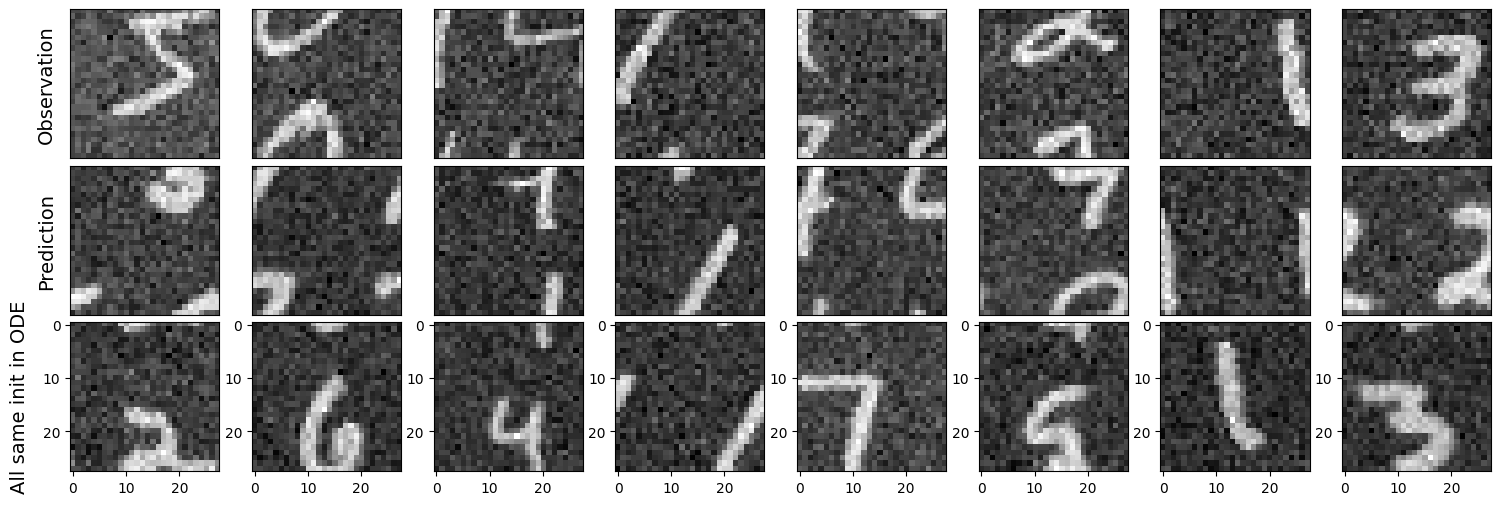

In [26]:
fig, axes = plt.subplots(3, 8, figsize=(17, 6))

for i in range(8):
    axes[0, i].imshow(observation[i, 0].cpu().numpy(), cmap='gray')
    axes[1, i].imshow(prediction[i, 0].cpu().numpy(), cmap='gray')
    axes[2, i].imshow(prediction_fixed_init[i, 0].cpu().numpy(), cmap='gray')
    for ax in (axes[0, i], axes[1, i]):
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_ylabel('Observation', fontsize=14, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('Prediction', fontsize=14, rotation=90, labelpad=10)
axes[2, 0].set_ylabel('All same init in ODE', fontsize=14, rotation=90, labelpad=10)


plt.subplots_adjust(left=0.05, wspace=0.05, hspace=0.05)
plt.show()

# Abulation Log

April 30:
- Architecture: Starting from Joan's architecture. Changed resblocks ot have a circular convolutions, which is `nn.Conv2D(..., padding_mode='circular')`. Has same problem as previous architecture.
- Architecture: Starting from Joan's architecture. Injected conditioner into all parts of the UNet (encoder, mid, and decode). The images look realistic but the generated images don't correspond with their conditioner-- additionallly if you change the inital_state (noise rng) it sometimes switches images (e.g. 5 becomes 2)
- Tried Joan's UNet for ~1500 epochs. Some of the images don't look realistic, like it messes it up. 